In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm import tqdm


import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.utils import save_image
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torchmetrics.image.fid import FrechetInceptionDistance

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

IMG_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-4
NUM_CLASSES = 4

DATA_ROOT = Path("/kaggle/input/datasets/alexislep/perio-kpt-1/perio_KPT")

# Remplacer par the chemins d'origine
DATA_ROOT = Path("/kaggle/input/datasets/alexislep/perio-kpt-1/perio_KPT")
LABELS_DIR = DATA_ROOT / "0_Baseline" / "labels"
IMAGES_DIR = DATA_ROOT / "0_Baseline" / "images"

IMG_SIZE_LDM = 128
BATCH_SIZE_LDM = 64
NUM_EPOCHS_LDM = 30
LR_LDM = 1e-4
NUM_TIMESTEPS = 500
BETA_START = 1e-4
BETA_END = 0.02

OUTPUT_DIR = Path("/kaggle/working/ldm_results")
OUTPUT_DIR.mkdir(exist_ok=True)

Device : cuda


In [622]:
!pip install torch-fidelity

In [ ]:

class PatchDataset(Dataset):
    def __init__(self, patches, labels, transform=None, target_size=IMG_SIZE):
       
        self.patches = []
        self.labels = labels
        self.target_size = target_size if isinstance(target_size, tuple) else (target_size, target_size)
        
        for patch in patches:
            if isinstance(patch, Image.Image):

                patch_resized = patch.resize(self.target_size, Image.BILINEAR)
            elif isinstance(patch, np.ndarray):

                patch_resized = cv2.resize(patch, self.target_size, interpolation=cv2.INTER_LINEAR)
                patch_resized = Image.fromarray(patch_resized)
            else:
                patch_resized = transforms.ToPILImage()(patch).resize(self.target_size, Image.BILINEAR)
            
            self.patches.append(patch_resized)
        
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        img = self.patches[idx]
        lbl = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, lbl


def distance(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def parse_yolov8_pose_line(line):
    parts = list(map(float, line.strip().split()))
    if len(parts) < 5 + 3*11:
        return None, None, None
    cls = int(parts[0])
    bbox = parts[1:5]
    kps = []
    for i in range(11):
        idx = 5 + i*3
        kps.append((parts[idx], parts[idx+1], int(parts[idx+2])))
    return cls, bbox, kps

def get_bone_loss_percentage(keypoints):
    if keypoints[0][2] == 0 or keypoints[1][2] == 0 or keypoints[2][2] == 0:
        return None
    cej = (keypoints[0][0], keypoints[0][1])
    bl = (keypoints[1][0], keypoints[1][1])
    rl = (keypoints[2][0], keypoints[2][1])
    d_cej_bl = distance(cej, bl)
    d_cej_rl = distance(cej, rl)
    if d_cej_rl == 0:
        return None
    return (d_cej_bl / d_cej_rl) * 100.0

def stage_from_bone_loss(pbl):
    if pbl < 10:
        return "Healthy", 0
    elif pbl < 30:
        return "Mild", 1
    elif pbl < 40:
        return "Moderate", 2
    else:
        return "Severe", 3

def extract_patch(image, bbox_norm, target_size=IMG_SIZE):
    w_img, h_img = image.size
    x_c, y_c, w_n, h_n = bbox_norm
    x = int((x_c - w_n/2) * w_img)
    y = int((y_c - h_n/2) * h_img)
    w = int(w_n * w_img)
    h = int(h_n * h_img)
    x = max(0, x)
    y = max(0, y)
    w = min(w, w_img - x)
    h = min(h, h_img - y)
    if w <= 0 or h <= 0:
        return None
    pad_x = int(w * 0.1)
    pad_y = int(h * 0.1)
    x1 = max(0, x - pad_x)
    y1 = max(0, y - pad_y)
    x2 = min(image.width, x + w + pad_x)
    y2 = min(image.height, y + h + pad_y)
    patch = image.crop((x1, y1, x2, y2))
    patch = patch.resize((target_size, target_size), Image.BILINEAR)
    return patch

def load_dataset_with_stages(labels_dir, images_dir, target_size=IMG_SIZE):
    patches, labels = [], []
    txt_files = list(labels_dir.glob("*.txt"))
    print(f"Fichiers .txt : {len(txt_files)}")
    skipped = 0
    for txt_file in txt_files:
        stem = txt_file.stem
        img_path = images_dir / f"{stem}.png"
        if not img_path.exists():
            continue
        image = Image.open(img_path).convert("RGB")
        with open(txt_file, 'r') as f:
            for line in f:
                cls, bbox, kps = parse_yolov8_pose_line(line)
                if bbox is None:
                    continue
                pbl = get_bone_loss_percentage(kps)
                if pbl is None:
                    skipped += 1
                    continue
                stage_name, stage_idx = stage_from_bone_loss(pbl)
                patch = extract_patch(image, bbox, target_size)
                if patch is not None:
                    patches.append(patch)
                    labels.append(stage_idx)
    print(f"Patches extraits : {len(patches)}")
    print(f"Patches ignorés : {skipped}")
    return patches, labels

def load_dataset_with_stages_and_mapping(labels_dir, images_dir, target_size=IMG_SIZE):
    """
    Version modifiée qui retourne aussi le mapping patch_idx -> img_stem
    """
    patches, labels = [], []
    patch_to_image = []  # Nouveau : mapping index patch → nom de l'image source
    txt_files = list(labels_dir.glob("*.txt"))
    print(f"Fichiers .txt : {len(txt_files)}")
    skipped = 0
    
    for txt_file in txt_files:
        stem = txt_file.stem
        img_path = images_dir / f"{stem}.png"
        if not img_path.exists():
            continue
        image = Image.open(img_path).convert("RGB")
        
        with open(txt_file, 'r') as f:
            for line in f:
                cls, bbox, kps = parse_yolov8_pose_line(line)
                if bbox is None:
                    continue
                pbl = get_bone_loss_percentage(kps)
                if pbl is None:
                    skipped += 1
                    continue
                stage_name, stage_idx = stage_from_bone_loss(pbl)
                patch = extract_patch(image, bbox, target_size)
                if patch is not None:
                    patches.append(patch)
                    labels.append(stage_idx)
                    patch_to_image.append(stem)  
    
    return patches, labels, patch_to_image

In [624]:
# ===== AJOUT : CALCUL CLINIQUE PBL =====
def compute_bone_loss_percent(cej, bone_level, apex):
    import numpy as np
    root_length = np.linalg.norm(np.array(apex) - np.array(cej))
    bone_loss = np.linalg.norm(np.array(bone_level) - np.array(cej))
    return 100 * bone_loss / max(root_length, 1e-6)

def pbl_to_stage(pbl):
    if pbl < 10:
        return "Healthy"
    elif pbl < 30:
        return "Mild"
    elif pbl < 50:
        return "Moderate"
    return "Severe"

Fichiers .txt : 192
Patches extraits : 193
Patches ignorés : 578

Distribution :
  Healthy: 59
  Mild: 102
  Moderate: 18
  Severe: 14

✅ Mapping patch→image créé : 193 associations

CLASS DISTRIBUTION

Total dataset (193 patches):
  Healthy    :  59 ( 30.6%) ███████████████
  Mild       : 102 ( 52.8%) ██████████████████████████
  Moderate   :  18 (  9.3%) ████
  Severe     :  14 (  7.3%) ███


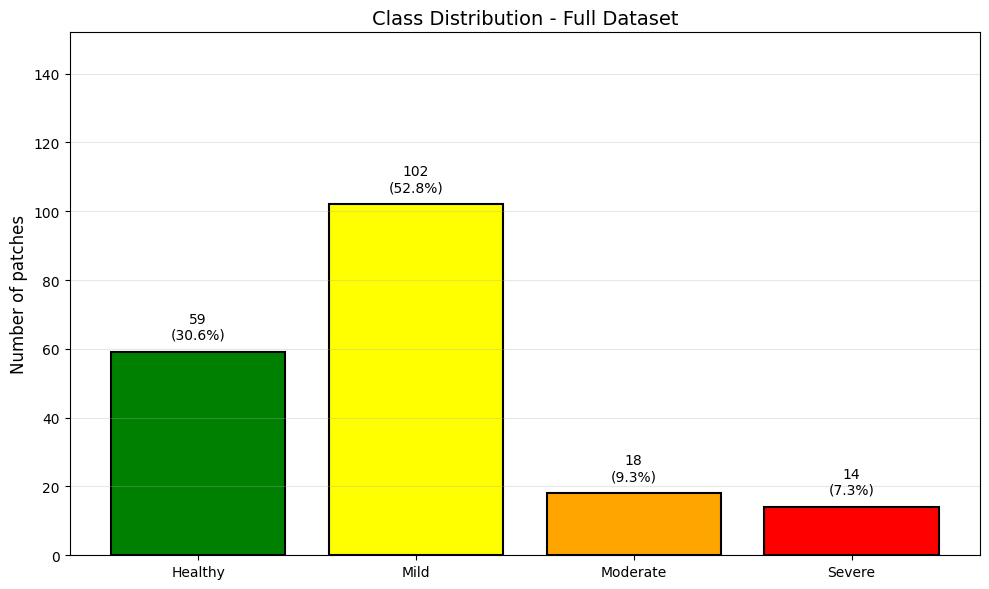

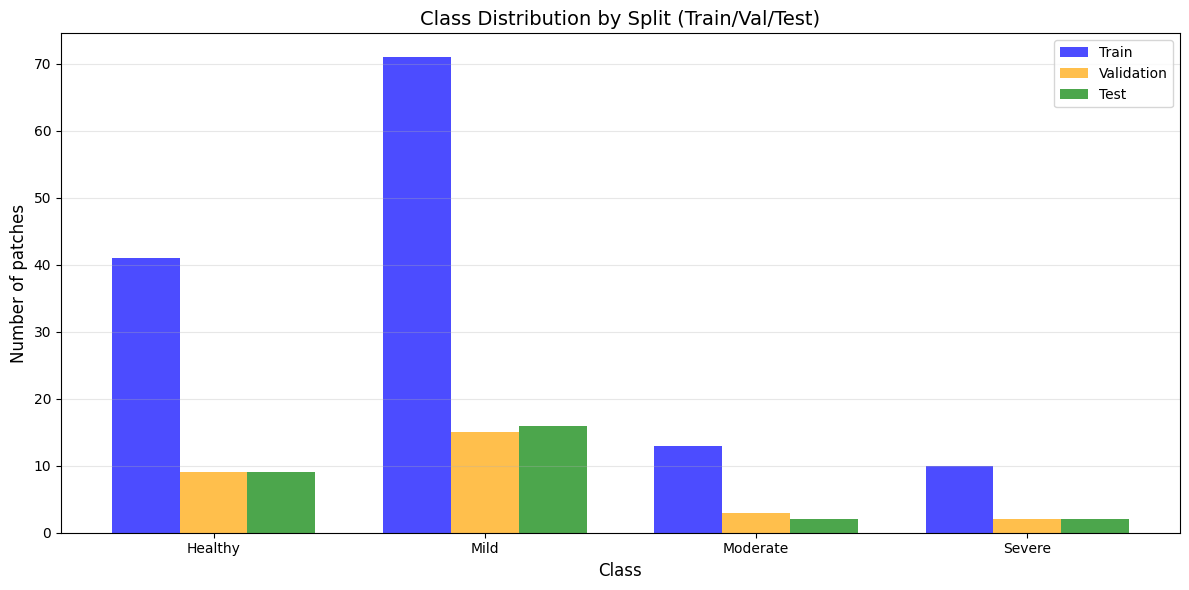

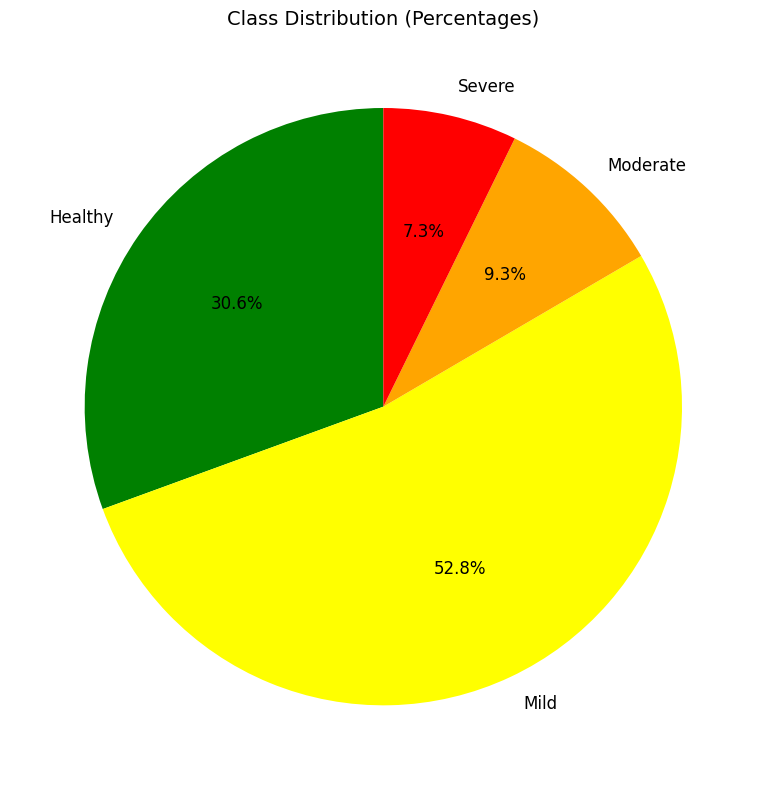


SUMMARY TABLE

Class        Count    Percentage  
-----------------------------------
Healthy            59        30.6%
Mild              102        52.8%
Moderate           18         9.3%
Severe             14         7.3%
-----------------------------------
TOTAL             193 100.0%      

NOTE ON CLASS IMBALANCE

The 'Severe' class has only 14 patches (7.3%)
compared to 102 patches for the 'Mild' class (52.8%).

This imbalance (Mild/Severe ratio = 7.3:1) explains in part:
- The LDM's difficulty in generating high-quality Severe patches
- The high FID score (generated distribution differs from real distribution)
- The lower AP Severe compared to other classes

To mitigate this issue, we use a WeightedRandomSampler 
during downstream classifier training.



In [ ]:

patches, labels, patch_to_image = load_dataset_with_stages_and_mapping(LABELS_DIR, IMAGES_DIR)

if len(patches) == 0:
    raise ValueError("Aucun patch extrait")

counts = Counter(labels)
stage_names = ["Healthy", "Mild", "Moderate", "Severe"]
values = [counts.get(i, 0) for i in range(4)]



import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Class names and colors
stage_names = ["Healthy", "Mild", "Moderate", "Severe"]
colors = ['green', 'yellow', 'orange', 'red']

# Count for entire dataset
counts = Counter(labels)
values = [counts.get(i, 0) for i in range(4)]

# Count for train/val/test splits if available
if 'train_idx' in dir() and 'val_idx' in dir() and 'test_idx' in dir():
    train_counts = Counter([labels[i] for i in train_idx])
    val_counts = Counter([labels[i] for i in val_idx])
    test_counts = Counter([labels[i] for i in test_idx])
    
    train_vals = [train_counts.get(i, 0) for i in range(4)]
    val_vals = [val_counts.get(i, 0) for i in range(4)]
    test_vals = [test_counts.get(i, 0) for i in range(4)]



print(f"\nTotal dataset ({len(labels)} patches):")
for name, val in zip(stage_names, values):
    pct = val / len(labels) * 100
    bar = "█" * int(pct / 2)
    print(f"  {name:10} : {val:3} ({pct:5.1f}%) {bar}")

# Plot 1: Global distribution
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(stage_names, values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of patches', fontsize=12)
ax.set_title('Class Distribution - Full Dataset', fontsize=14)
ax.set_ylim(0, max(values) + 50)

for bar, val, name in zip(bars, values, stage_names):
    pct = val / len(labels) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_total.png", dpi=150)
plt.show()

# Plot 2: Distribution by split (train/val/test)
if 'train_idx' in dir():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(stage_names))
    width = 0.25
    
    ax.bar(x - width, train_vals, width, label='Train', color='blue', alpha=0.7)
    ax.bar(x, val_vals, width, label='Validation', color='orange', alpha=0.7)
    ax.bar(x + width, test_vals, width, label='Test', color='green', alpha=0.7)
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Number of patches', fontsize=12)
    ax.set_title('Class Distribution by Split (Train/Val/Test)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(stage_names)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "class_distribution_splits.png", dpi=150)
    plt.show()

# Plot 3: Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(values, labels=stage_names, colors=colors, 
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'fontsize': 12})
ax.set_title('Class Distribution (Percentages)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_pie.png", dpi=150)
plt.show()

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"\n{'Class':12} {'Count':8} {'Percentage':12}")
print("-" * 35)
for name, val in zip(stage_names, values):
    pct = val / len(labels) * 100
    print(f"{name:12} {val:8} {pct:11.1f}%")
print("-" * 35)
print(f"{'TOTAL':12} {len(labels):8} {'100.0%':12}")

# Highlight imbalance issue

severe_count = values[3]
mild_count = values[1]
ratio = mild_count / severe_count if severe_count > 0 else float('inf')



In [ ]:

from sklearn.model_selection import train_test_split

train_idx, temp_idx = train_test_split(
    list(range(len(labels))), 
    test_size=0.3, 
    stratify=labels, 
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    stratify=[labels[i] for i in temp_idx], 
    random_state=SEED
)

# Transformations
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Creation of datasets
train_dataset = PatchDataset(
    [patches[i] for i in train_idx], 
    [labels[i] for i in train_idx], 
    train_transform
)

val_dataset = PatchDataset(
    [patches[i] for i in val_idx], 
    [labels[i] for i in val_idx], 
    eval_transform
)

test_dataset = PatchDataset(
    [patches[i] for i in test_idx], 
    [labels[i] for i in test_idx], 
    eval_transform
)

# Creation of dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



Train: 135, Val: 29, Test: 29
✅ Dataloaders créés avec succès


=== Entraînement du baseline ===
Epoch 05/30 | Train Acc: 0.7407 | Val Acc: 0.5172
Epoch 10/30 | Train Acc: 0.9333 | Val Acc: 0.5172
Epoch 15/30 | Train Acc: 0.9630 | Val Acc: 0.4828
Epoch 20/30 | Train Acc: 0.9852 | Val Acc: 0.4828
Epoch 25/30 | Train Acc: 0.9926 | Val Acc: 0.4483
Epoch 30/30 | Train Acc: 0.9926 | Val Acc: 0.5517

Meilleure accuracy validation : 0.5517

=== Évaluation ===

=== Classification Report ===
              precision    recall  f1-score   support

     Healthy       0.50      0.33      0.40         9
        Mild       0.65      0.81      0.72        16
    Moderate       0.00      0.00      0.00         2
      Severe       0.33      0.50      0.40         2

    accuracy                           0.59        29
   macro avg       0.37      0.41      0.38        29
weighted avg       0.54      0.59      0.55        29


=== Average Precision ===
AP Healthy: 0.5167
AP Mild: 0.7903
AP Moderate: 0.2917
AP Severe: 0.3750
mAP : 0.4934


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


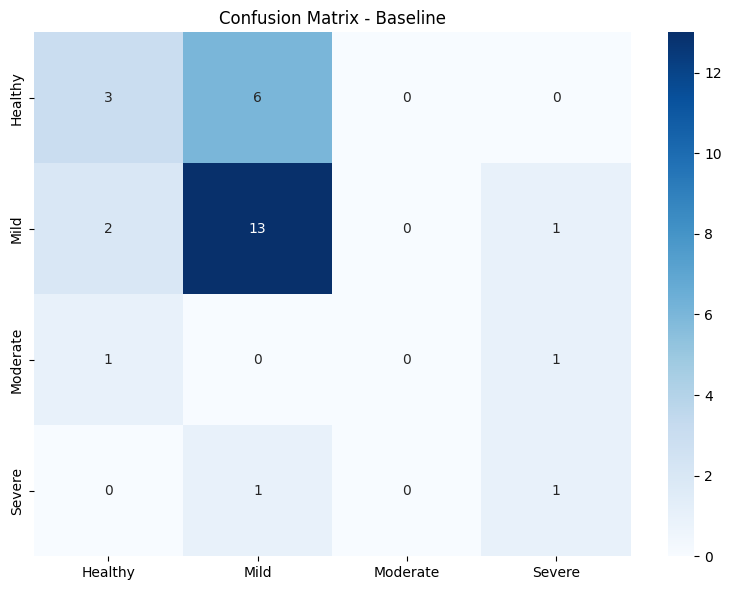

In [ ]:


def build_resnet18(num_classes=NUM_CLASSES):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0,0,0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == lbls).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0,0,0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            total += imgs.size(0)
    return total_loss/total, correct/total

def train_model(model, train_loader, val_loader, epochs=NUM_EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    best_val_acc = 0
    best_weights = None
    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = validate(model, val_loader, criterion)
        scheduler.step()
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = {k:v.clone() for k,v in model.state_dict().items()}
        if (epoch+1)%5==0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {tr_acc:.4f} | Val Acc: {vl_acc:.4f}")
    model.load_state_dict(best_weights)
    torch.save(best_weights, "/kaggle/working/baseline_resnet18.pth")
    print(f"\nMeilleure accuracy validation : {best_val_acc:.4f}")
    return model

def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs)
    target_names = ["Healthy", "Mild", "Moderate", "Severe"]
    print("\n=== Classification Report ===")
    print(classification_report(all_labels, all_preds, target_names=target_names))
    print("\n=== Average Precision ===")
    all_labels_arr = np.array(all_labels)
    all_probs_arr = np.array(all_probs)
    y_bin = label_binarize(all_labels_arr, classes=[0,1,2,3])
    ap_scores = {}
    for i, name in enumerate(target_names):
        ap = average_precision_score(y_bin[:,i], all_probs_arr[:,i])
        ap_scores[name] = ap
        print(f"AP {name}: {ap:.4f}")
    print(f"mAP : {np.mean(list(ap_scores.values())):.4f}")
    cm = confusion_matrix(all_labels_arr, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title("Confusion Matrix - Baseline")
    plt.tight_layout()
    plt.show()

baseline_model = build_resnet18()
baseline_model = train_model(baseline_model, train_loader, val_loader)

evaluate(baseline_model, test_loader)

In [ ]:


class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

In [ ]:

def linear_beta_schedule(timesteps, beta_start=BETA_START, beta_end=BETA_END):
    return torch.linspace(beta_start, beta_end, timesteps)

betas = linear_beta_schedule(NUM_TIMESTEPS).to(DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_cumprod_t = sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
    return sqrt_alpha_cumprod_t * x0 + sqrt_one_minus_alpha_cumprod_t * noise, noise

def p_sample(model, x, t, class_labels):
    t_tensor = torch.full((x.shape[0],), t, device=x.device, dtype=torch.long)
    pred_noise = model(x, t_tensor, class_labels)
    alpha_t = alphas[t]
    alpha_cumprod_t = alphas_cumprod[t]
    beta_t = betas[t]
    sqrt_recip_alpha_t = 1.0 / torch.sqrt(alpha_t)
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
    mean = sqrt_recip_alpha_t * (x - beta_t * pred_noise / sqrt_one_minus_alpha_cumprod_t)
    if t == 0:
        return mean
    else:
        return mean + torch.sqrt(beta_t) * torch.randn_like(x)

@torch.no_grad()
def p_sample_loop(model, shape, class_labels):
    x = torch.randn(shape, device=DEVICE)
    for t in reversed(range(NUM_TIMESTEPS)):
        x = p_sample(model, x, t, class_labels)
    return x

def p_sample_with_mask(model, x, mask, t, class_labels):
    """
    Version avec masque de la fonction p_sample.
    """
    t_tensor = torch.full((x.shape[0],), t, device=x.device, dtype=torch.long)
    pred_noise = model(x, mask, t_tensor, class_labels)
    alpha_t = alphas[t]
    alpha_cumprod_t = alphas_cumprod[t]
    beta_t = betas[t]
    
    sqrt_recip_alpha_t = 1.0 / torch.sqrt(alpha_t)
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
    
    mean = sqrt_recip_alpha_t * (x - beta_t * pred_noise / sqrt_one_minus_alpha_cumprod_t)
    
    if t == 0:
        return mean
    else:
        return mean + torch.sqrt(beta_t) * torch.randn_like(x)

@torch.no_grad()
def p_sample_loop_with_mask(model, shape, mask, class_labels):
    
    x = torch.randn(shape, device=DEVICE)
    for t in reversed(range(NUM_TIMESTEPS)):
        x = p_sample_with_mask(model, x, mask, t, class_labels)
    return x

In [ ]:

class ImprovedVAE(nn.Module):
    def __init__(self, in_channels=3, latent_channels=8, hidden_dims=[64, 128, 256, 512]):
        super().__init__()
        self.latent_channels = latent_channels
      
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(),
                    nn.Dropout2d(0.1)
                )
            )
            in_channels = h_dim
        
        self.encoder = nn.Sequential(*modules)
        self.fc_mu = nn.Conv2d(hidden_dims[-1], latent_channels, kernel_size=3, stride=1, padding=1)
        self.fc_var = nn.Conv2d(hidden_dims[-1], latent_channels, kernel_size=3, stride=1, padding=1)
        

        modules = []
        self.decoder_input = nn.Conv2d(latent_channels, hidden_dims[-1], kernel_size=3, stride=1, padding=1)
        
        hidden_dims.reverse()
        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(hidden_dims[i], hidden_dims[i+1], kernel_size=3, stride=2, padding=1, output_padding=1),
                    nn.BatchNorm2d(hidden_dims[i+1]),
                    nn.LeakyReLU()
                )
            )
        
        self.decoder = nn.Sequential(*modules)
        self.final_layer = nn.Sequential(
            nn.ConvTranspose2d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(hidden_dims[-1]),
            nn.LeakyReLU(),
            nn.Conv2d(hidden_dims[-1], 3, kernel_size=3, padding=1),
            nn.Tanh()
        )
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.decoder_input(z)
        h = self.decoder(h)
        return self.final_layer(h)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var


def train_vae_improved(vae, dataloader, epochs=75):
    """Version avec learning rate plus bas et beta plus faible"""
    
    optimizer = optim.Adam(vae.parameters(), lr=5e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    
    best_loss = float('inf')
    best_weights = None
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        vae.train()
        
        for imgs, _ in tqdm(dataloader, desc=f"VAE Epoch {epoch+1}"):
            imgs = imgs.to(DEVICE)
            recon, mu, log_var = vae(imgs)
            
            recon_loss = F.mse_loss(recon, imgs)
            kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / imgs.shape[0]
            beta = 0.0001  # Fixe, pas de scheduling
            
            loss = recon_loss + beta * kl_loss
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_weights = vae.state_dict().copy()
            torch.save(best_weights, "/kaggle/working/vae_best.pth")
            print(f"  ✅ Epoch {epoch+1}: nouveau meilleur (loss: {best_loss:.6f})")
        
        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}, Best: {best_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    vae.load_state_dict(best_weights)
    
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training Loss')
    plt.yscale('log')
    plt.grid(True)
    plt.savefig(OUTPUT_DIR / "vae_loss_curve.png")
    plt.show()
    
    return vae



In [ ]:


@torch.no_grad()
def generate_with_mask(self, mask_condition, class_labels):
    """
    Génération guidée par un masque anatomique.
    Le masque est déjà à la bonne taille (128x128).
    """
    batch_size = mask_condition.shape[0]
    latent_shape = (batch_size, self.vae.latent_channels, 16, 16)
    
    z = torch.randn(latent_shape, device=self.device)
    
    if masks.dim() == 3:
        masks = masks.unsqueeze(0)
    masks_latent = F.interpolate(masks, size=z.shape[-2:], mode='nearest')
    
    for t in reversed(range(NUM_TIMESTEPS)):
        t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)
        pred_noise = self.unet(z, t_tensor, class_labels)
        
        alpha_t = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta_t = betas[t]
        sqrt_recip_alpha_t = 1.0 / torch.sqrt(alpha_t)
        sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
        
        mean = sqrt_recip_alpha_t * (z - beta_t * pred_noise / sqrt_one_minus_alpha_cumprod_t)
        
        if t > 0:
            z = mean + torch.sqrt(beta_t) * torch.randn_like(z)
        else:
            z = mean
    
    images = self.vae.decode(z)
    return images  

In [ ]:

patches, labels, patch_to_image = load_dataset_with_stages_and_mapping(LABELS_DIR, IMAGES_DIR)

print(f"\nExemple de mapping : patch 0 → image {patch_to_image[0]}")
print(f"Patch 1 → image {patch_to_image[1]}")

Fichiers .txt : 192
Patches extraits : 193
Patches ignorés : 578

Exemple de mapping : patch 0 → image Image18
Patch 1 → image Image18


In [ ]:

def parse_yolo_segmentation(line, img_size=(640, 640)):
    
    parts = list(map(float, line.strip().split()))
    if len(parts) < 7:  
        return None
    
    cls = int(parts[0])
    coords = parts[1:]
    
    h, w = img_size
    points = []
    for i in range(0, len(coords), 2):
        if i+1 < len(coords):
            x = int(coords[i] * w)
            y = int(coords[i+1] * h)
            points.append([x, y])
    
    if len(points) < 3:
        return None
    
    mask = np.zeros((h, w), dtype=np.uint8)
    
    pts = np.array(points, dtype=np.int32)
    cv2.fillPoly(mask, [pts], 1)
    
    return mask, cls

def load_masks_for_image(img_stem, labels_dir, img_size=(640, 640)):
    
    label_path = labels_dir/ f"{img_stem}.txt"
    if not label_path.exists():
        return None
    
    merged_mask = np.zeros(img_size, dtype=np.uint8)
    
    with open(label_path, 'r') as f:
        for line in f:
            result = parse_yolo_segmentation(line, img_size)
            if result is not None:
                mask, cls = result
                merged_mask = np.maximum(merged_mask, mask)  
    return merged_mask

test_stem = "6_165"  
test_mask = load_masks_for_image(test_stem, LABELS_DIR)

if test_mask is not None:
    print(f"Masque créé : shape {test_mask.shape}")
    print(f"Valeurs uniques : {np.unique(test_mask)}")
    
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(test_mask, cmap='gray')
    plt.title("Masque fusionné")
    plt.subplot(1,2,2)
    plt.hist(test_mask.ravel(), bins=2)
    plt.title("Histogramme")
    plt.show()

In [ ]:


class AnatomicalLossForLatentLDM(nn.Module):
    def __init__(self, anatomical_weight=3.0):
        super().__init__()
        self.anatomical_weight = anatomical_weight
    
    def forward(self, pred_noise, noise, masks, latent_size):
        
        masks_latent = F.interpolate(masks, size=latent_size, mode='nearest')
        
        mse_per_pixel = (pred_noise - noise) ** 2
        weight_map = 1.0 + (self.anatomical_weight - 1.0) * masks_latent
        
        return (mse_per_pixel * weight_map).mean()

In [ ]:

def check_vae_quality(vae, dataloader, retrain_threshold=0.05):
    
    vae.eval()
    with torch.no_grad():
        imgs, _ = next(iter(dataloader))
        imgs = imgs[:8].to(DEVICE)
        recon, mu, log_var = vae(imgs)
        
        mse = F.mse_loss(recon, imgs).item()
        mu_std = mu.std().item()
        
        print(f"📊 Diagnostic VAE:")
        print(f"   MSE reconstruction: {mse:.4f} (seuil recommandé: <{retrain_threshold})")
        print(f"   Mu - mean: {mu.mean():.3f}, std: {mu_std:.3f}")
        print(f"   Latent shape: {mu.shape}")
        
        is_acceptable = mse < retrain_threshold and mu_std > 0.5
        
        if is_acceptable:
            print("   VAE ready")
        else:
            print(" VAE not ready)")
           
        
        return is_acceptable, mse, mu_std

In [ ]:



def compute_fid(real_imgs, fake_imgs):
    """Calcule le FID entre deux ensembles d'images normalisées [0,1]"""
    fid = FrechetInceptionDistance(normalize=True).to(DEVICE)
    
# Convertir en uint8 for FID
    if real_imgs.max() <= 1.0:
        real_imgs = (real_imgs * 255).byte()
    if fake_imgs.max() <= 1.0:
        fake_imgs = (fake_imgs * 255).byte()
    
    fid.update(real_imgs.to(DEVICE), real=True)
    fid.update(fake_imgs.to(DEVICE), real=False)
    return fid.compute().item()

In [ ]:
# ===== CELLULE - FONCTIONS D'ENTRAÎNEMENT MANQUANTES =====

def get_mask_for_patch_simple(patch_idx, labels_dir, patch_to_image, target_size=16, img_size=(640, 640)):
    """
    Récupère le masque BBOX simple pour un patch.
    Version simplifiée basée sur la bounding box uniquement.
    """
    img_stem = patch_to_image[patch_idx]
    label_path = labels_dir / f"{img_stem}.txt"
    
    if not label_path.exists():
        return None
    
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        cls, bbox, kps = parse_yolov8_pose_line(line)
        if bbox is not None:
# Créer a masque simple à partir de the bounding box
            h, w = img_size
            x_c, y_c, w_n, h_n = bbox
            
            x = int((x_c - w_n/2) * w)
            y = int((y_c - h_n/2) * h)
            width = int(w_n * w)
            height = int(h_n * h)
            
# Ajouter a petite marge
            margin_x = int(width * 0.1)
            margin_y = int(height * 0.1)
            
            x1 = max(0, x - margin_x)
            y1 = max(0, y - margin_y)
            x2 = min(w, x + width + margin_x)
            y2 = min(h, y + height + margin_y)
            
            mask = np.zeros((h, w), dtype=np.uint8)
            mask[y1:y2, x1:x2] = 1
            mask_resized = cv2.resize(mask, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
            
            return mask_resized.astype(np.float32)
    
    return None
# Ajoutez cette fonction avant de l'utiliser (dans a cellule avant celle qui génère l'erreur)

def prepare_latent_dataset_with_masks(vae, patches, labels, patch_to_image, labels_dir, batch_size=16):
    """
    Prépare les latents et les masques pour l'entraînement du LDM.
    """
    vae.eval()
    
# Transform for the patches
    transform_temp = transforms.Compose([
        transforms.Resize((IMG_SIZE_LDM, IMG_SIZE_LDM)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # normalisation entre -1 and 1
    ])
    
    temp_dataset = PatchDataset(patches, labels, transform_temp)
    loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)
    
    latents_list = []
    labels_list = []
    masks_list = []
    
    patch_idx = 0
    
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Encodage des images"):
            imgs = imgs.to(DEVICE)
            mu, _ = vae.encode(imgs)
            latents_list.append(mu.cpu())
            labels_list.append(lbls)
            
# Récupérer the masques for chaque patch
            for i in range(imgs.shape[0]):
# Essayer d'abord the heatmap anatomique
                heatmap = get_heatmap_for_patch(
                    patch_idx + i, labels_dir, patch_to_image, 
                    target_size=IMG_SIZE_LDM, sigma=15
                )
                
                if heatmap is not None:
                    mask = torch.from_numpy(heatmap).float()
                else:
# Fallback: masque aléatoire if pas de heatmap
                    mask = torch.zeros(IMG_SIZE_LDM, IMG_SIZE_LDM).float()
# Optionnel: centre du patch comme région d'intérêt
                    center = IMG_SIZE_LDM // 2
                    mask[center-20:center+20, center-20:center+20] = 1.0
                
                masks_list.append(mask.unsqueeze(0))  # (1, H, W)
            
            patch_idx += imgs.shape[0]
    
    latents = torch.cat(latents_list, dim=0)
    labels_tensor = torch.cat(labels_list, dim=0)
    masks = torch.stack(masks_list)  # (N, 1, H, W)
    
    
    return latents, labels_tensor, masks

def train_ldm_model(vae, train_loader, model_name, epochs=75):
    
    print(f"\n{'='*50}")
    print(f"Entraînement: {model_name}")
    print(f"{'='*50}")
    
# Initialiser the UNet latent
    latent_unet = LatentDiffusionUNet8ch(
        in_channels=vae.latent_channels,
        out_channels=vae.latent_channels,
        num_classes=NUM_CLASSES
    ).to(DEVICE)
    
    guided_ldm = AnatomicallyGuidedLDM8ch(vae, latent_unet, DEVICE, anatomical_weight=3.0)
    
    optimizer = optim.Adam(guided_ldm.unet.parameters(), lr=LR_LDM)
    
    for epoch in range(epochs):
        total_loss = 0
        for z, lbls, msk in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            z = z.to(DEVICE)
            lbls = lbls.to(DEVICE)
            msk = msk.to(DEVICE)
            
            t = torch.randint(0, NUM_TIMESTEPS, (z.shape[0],), device=DEVICE)
            noise = torch.randn_like(z)
            z_noisy, _ = q_sample(z, t, noise)
            pred_noise = guided_ldm.unet(z_noisy, t, lbls)
            
            mse_per_pixel = (pred_noise - noise) ** 2
            masks_latent = F.interpolate(msk, size=z.shape[-2:], mode='nearest')
            weight_map = 1.0 + (guided_ldm.anatomical_weight - 1.0) * masks_latent
            loss = (mse_per_pixel * weight_map).mean()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    print(f"✅ {model_name} entraîné")
    return guided_ldm


def train_ldm_baseline(vae, latents_loader, model_name, epochs=75):
    
    print(f"\n{'='*50}")
    print(f"Entraînement: {model_name} (SANS contrainte)")
    print(f"{'='*50}")
    
    latent_unet = LatentDiffusionUNet8ch(
        in_channels=vae.latent_channels,
        out_channels=vae.latent_channels,
        num_classes=NUM_CLASSES
    ).to(DEVICE)
    
    optimizer = optim.Adam(latent_unet.parameters(), lr=LR_LDM)
    
    for epoch in range(epochs):
        total_loss = 0
        for z, lbls in tqdm(latents_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            z = z.to(DEVICE)
            lbls = lbls.to(DEVICE)
            
            t = torch.randint(0, NUM_TIMESTEPS, (z.shape[0],), device=DEVICE)
            noise = torch.randn_like(z)
            z_noisy, _ = q_sample(z, t, noise)
            pred_noise = latent_unet(z_noisy, t, lbls)
            
            loss = F.mse_loss(pred_noise, noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(latents_loader)
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    print(f"✅ {model_name} entraîné")
    
    class BaselineLDMWrapper:
        def __init__(self, vae, unet, device):
            self.vae = vae
            self.unet = unet
            self.device = device
        @torch.no_grad()
        def generate_with_mask(self, mask_condition, class_labels):
            batch_size = mask_condition.shape[0]
            latent_shape = (batch_size, self.vae.latent_channels, 16, 16)
            
            z = torch.randn(latent_shape, device=self.device)
            
            if mask_condition.dim() == 3:
                mask_condition = mask_condition.unsqueeze(0)
            mask_latent = F.interpolate(mask_condition, size=(16, 16), mode='nearest')
            
            for t in reversed(range(NUM_TIMESTEPS)):
                t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)
                pred_noise = self.unet(z, t_tensor, class_labels)
                
                alpha_t = alphas[t]
                beta_t = betas[t]
                sqrt_recip_alpha_t = 1.0 / torch.sqrt(alpha_t)
                sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
                
                mean = sqrt_recip_alpha_t * (z - beta_t * pred_noise / sqrt_one_minus_alpha_cumprod_t)
                
                if t > 0:
                    z = mean + torch.sqrt(beta_t) * torch.randn_like(z)
                else:
                    z = mean
            
            return self.vae.decode(z)
       
    
    return BaselineLDMWrapper(vae, latent_unet, DEVICE)
    
if 'patches' not in dir() or 'labels' not in dir():
    print("patches not loaded!")
else:
    latents_all, labels_all, masks_all = prepare_latent_dataset_with_masks(
        vae=vae,
        patches=patches,
        labels=labels,
        patch_to_image=patch_to_image,
        labels_dir=LABELS_DIR,
        batch_size=16
    )
    
latent_dataset_with_masks = LatentDatasetWithMasks(latents_all, labels_all, masks_all)
train_loader_with_masks = DataLoader(latent_dataset_with_masks, batch_size=BATCH_SIZE_LDM, shuffle=True)
    
latent_dataset_baseline = torch.utils.data.TensorDataset(latents_all, labels_all)
train_loader_baseline = DataLoader(latent_dataset_baseline, batch_size=BATCH_SIZE_LDM, shuffle=True)


Encodage des images: 100%|██████████| 13/13 [00:02<00:00,  4.61it/s]

✅ Latents: torch.Size([193, 8, 8, 8])
✅ Labels: torch.Size([193])
✅ Masks: torch.Size([193, 1, 128, 128])



PIPELINE DE COMPARAISON - 3 MODÈLES LDM

[ÉTAPE 1/4] Entraînement du VAE (8 canaux latents)...


VAE Epoch 1: 100%|██████████| 13/13 [00:00<00:00, 15.87it/s]


  ✅ Epoch 1: nouveau meilleur (loss: 0.693269)


VAE Epoch 2: 100%|██████████| 13/13 [00:00<00:00, 17.27it/s]


  ✅ Epoch 2: nouveau meilleur (loss: 0.492776)


...

  ✅ Epoch 275: nouveau meilleur (loss: 0.082248)


VAE Epoch 280: 100%|██████████| 13/13 [00:00<00:00, 17.01it/s]


Epoch 280/300, Loss: 0.119267, Best: 0.082248, LR: 1.22e-08


VAE Epoch 300: 100%|██████████| 13/13 [00:00<00:00, 17.22it/s]


Epoch 300/300, Loss: 0.092560, Best: 0.082248, LR: 1.22e-08


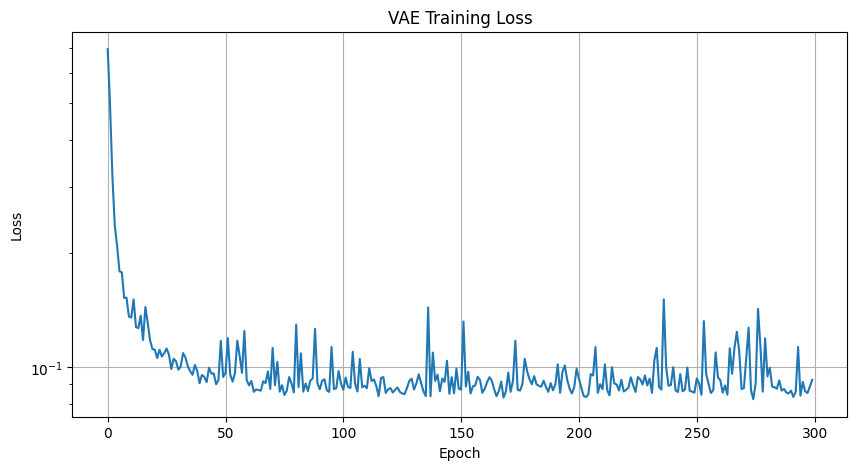


📊 VAE final - Meilleure loss: 0.082248
✅ VAE entraîné

Entraînement: Baseline LDM (sans masque) (SANS contrainte)


Epoch 10/120: 100%|██████████| 4/4 [00:00<00:00, 29.47it/s]


  Epoch 10/120, Loss: 0.8367


Epoch 20/120: 100%|██████████| 4/4 [00:00<00:00, 30.49it/s]


  Epoch 20/120, Loss: 0.6866


...

  Epoch 90/120, Loss: 0.2304


Epoch 100/120: 100%|██████████| 4/4 [00:00<00:00, 28.48it/s]


  Epoch 100/120, Loss: 0.4324


Epoch 120/120: 100%|██████████| 4/4 [00:00<00:00, 28.65it/s]


  Epoch 120/120, Loss: 0.2001
✅ LDM + contrainte heatmap entraîné
FID Baseline: 490.21
FID BBOX: 478.06
FID Heatmap: 491.44


In [ ]:


all_dataset = PatchDataset(patches, labels, eval_transform)
train_loader_vae = DataLoader(all_dataset, batch_size=16, shuffle=True)

vae = ImprovedVAE(latent_channels=8).to(DEVICE)
vae = train_vae_improved(vae, train_loader_vae, epochs=300)
print("VAE entraîné")

# Model 1: Baseline (without contrainte)
ldm_baseline = train_ldm_baseline(vae, train_loader_baseline, "Baseline LDM (sans masque)", epochs=120)
    
# Model 2: LDM with contrainte BBOX
ldm_bbox = train_ldm_model(vae, train_loader_with_masks, "LDM + contrainte BBOX", epochs=120)
    
# Model 3: LDM with contrainte heatmap
ldm_heatmap = train_ldm_model(vae, train_loader_with_masks, "LDM + contrainte heatmap", epochs=120)



severe_indices = [i for i, lbl in enumerate(labels) if lbl == 3]
real_imgs = torch.stack([transforms.ToTensor()(patches[i]) for i in severe_indices[:50]]).to(DEVICE)

def get_fid(model, num_samples=50, use_masks=True):
    global real_imgs  # ← Ajoutez cette ligne for utiliser the variable globale
    
    fid = FrechetInceptionDistance(normalize=True).to(DEVICE)
    
    fake_imgs = []
    batch_size = 8
    
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            current_batch = min(batch_size, num_samples - i)
            
# Create mask based on use_masks flag
            if use_masks:
                mask = torch.ones(current_batch, 1, 128, 128).to(DEVICE)
            else:
                mask = torch.zeros(current_batch, 1, 128, 128).to(DEVICE)
            
# Generate images
            gen = model.generate_with_mask(
                mask, 
                torch.full((current_batch,), 3, device=DEVICE)
            )
            fake_imgs.append(torch.clamp((gen + 1) / 2, 0, 1))
    
    fake_imgs = torch.cat(fake_imgs, dim=0)[:num_samples]
    
    fid.update(real_imgs[:num_samples], real=True)
    fid.update(fake_imgs, real=False)
    
    return fid.compute().item()

print("FID Baseline:", f"{get_fid(ldm_baseline, use_masks=False):.2f}")
print("FID BBOX:", f"{get_fid(ldm_bbox):.2f}")
print("FID Heatmap:", f"{get_fid(ldm_heatmap):.2f}")

guided_ldm = ldm_heatmap

In [ ]:

print("\n" + "="*60)
print("GÉNÉRATION DE PATCHES SEVERE AVEC LDM GUIDÉ")
print("="*60)

# Récupérer the masques heatmap of patches Severe existants
severe_indices = [i for i, lbl in enumerate(labels) if lbl == 3]
real_masks = []

for idx in severe_indices:
    heatmap = get_heatmap_for_patch(idx, LABELS_DIR, patch_to_image, target_size=128, sigma=15)
    if heatmap is not None:
        mask_tensor = torch.from_numpy(heatmap).float().unsqueeze(0).unsqueeze(0)
        real_masks.append(mask_tensor)

print(f"✅ {len(real_masks)} masques heatmap de référence")

# Générer 200 patches Severe 
num_generate = 200
all_generated_patches = []
masks_batch = torch.cat(real_masks, dim=0).to(DEVICE)

guided_ldm.unet.eval()

with torch.no_grad():
    for i in tqdm(range(0, num_generate, len(real_masks)), desc="Génération"):
        current_batch = min(len(real_masks), num_generate - i)
        gen = guided_ldm.generate_with_mask(
            mask_condition=masks_batch[:current_batch],
            class_labels=torch.full((current_batch,), 3, device=DEVICE)
        )
        gen_img = (gen + 1) / 2
        gen_img = torch.clamp(gen_img, 0, 1)
        for j in range(gen_img.shape[0]):
            img_pil = transforms.ToPILImage()(gen_img[j].cpu())
            all_generated_patches.append(img_pil)

guided_ldm.unet.train()

print(f"✅ {len(all_generated_patches)} patches générés (classe Severe)")

torch.save(all_generated_patches, OUTPUT_DIR / "generated_severe_patches.pt")


GÉNÉRATION DE PATCHES SEVERE AVEC LDM GUIDÉ
✅ 14 masques heatmap de référence


Génération: 100%|██████████| 15/15 [00:32<00:00,  2.20s/it]


✅ 200 patches générés (classe Severe)


In [ ]:


train_indices, _ = train_test_split(
    list(range(len(labels))), 
    test_size=0.30, 
    stratify=labels, 
    random_state=SEED
)

original_train_labels = [labels[i] for i in train_indices]
n_severe_real = sum(1 for l in original_train_labels if l == 3)
n_mild_real = sum(1 for l in original_train_labels if l == 1)
n_healthy_real = sum(1 for l in original_train_labels if l == 0)
n_moderate_real = sum(1 for l in original_train_labels if l == 2)

print(f"Distribution originale (train):")
print(f"  Healthy: {n_healthy_real}")
print(f"  Mild: {n_mild_real}") 
print(f"  Moderate: {n_moderate_real}")
print(f"  Severe: {n_severe_real}")

if 'all_generated_patches' not in dir() or len(all_generated_patches) == 0:
    print("\n⚠️ Génération des patches Severe...")

else:
    print(f"\n✅ {len(all_generated_patches)} patches Severe déjà générés")

ratios = [0.5, 1.0, 2.0, 5.0]  
augmented_datasets = {}

for ratio in ratios:
    n_to_add = min(int(n_severe_real * ratio), len(all_generated_patches))
    
    patches_aug = [patches[i] for i in train_indices] + all_generated_patches[:n_to_add]
    labels_aug = original_train_labels + [3] * n_to_add
    
    augmented_datasets[ratio] = (patches_aug, labels_aug)
    
    print(f"\nRatio {ratio:.1f}×: {n_to_add} patches ajoutés → total Severe = {n_severe_real + n_to_add}")


torch.save(augmented_datasets, OUTPUT_DIR / "augmented_datasets_ratios.pt")



AUGMENTATION DES DONNÉES - MULTIPLES RATIOS
Distribution originale (train):
  Healthy: 41
  Mild: 71
  Moderate: 13
  Severe: 10

✅ 200 patches Severe déjà générés

Ratio 0.5×: 5 patches ajoutés → total Severe = 15

Ratio 1.0×: 10 patches ajoutés → total Severe = 20

Ratio 2.0×: 20 patches ajoutés → total Severe = 30

Ratio 5.0×: 50 patches ajoutés → total Severe = 60

✅ Datasets sauvegardés


In [ ]:
def train_and_evaluate_classifier(patches_train, labels_train, model_name, test_loader, epochs=100):
    
    
# Transformations for training
    train_transform_local = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    eval_transform_local = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
# Split into train/val (80/20)
    indices = list(range(len(labels_train)))
    train_idx_local, val_idx_local = train_test_split(
        indices, test_size=0.2, stratify=labels_train, random_state=SEED
    )
    
    train_subset = PatchDataset(
        [patches_train[i] for i in train_idx_local],
        [labels_train[i] for i in train_idx_local],
        train_transform_local
    )
    
    val_subset = PatchDataset(
        [patches_train[i] for i in val_idx_local],
        [labels_train[i] for i in val_idx_local],
        eval_transform_local
    )
    
# Weighted sampler for class balancing
    class_counts = Counter([labels_train[i] for i in train_idx_local])
    class_weights = {c: 1.0 / class_counts[c] for c in range(4)}
    sample_weights = [class_weights[labels_train[i]] for i in train_idx_local]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    train_loader_local = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler)
    val_loader_local = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
    
# Train model
    model = build_resnet18()
    model = train_model(model, train_loader_local, val_loader_local, epochs=epochs)
    
# Evaluate on test set
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_labels.extend(lbls.numpy())
            all_probs.extend(probs)
    
    all_labels_arr = np.array(all_labels)
    all_probs_arr = np.array(all_probs)
    y_bin = label_binarize(all_labels_arr, classes=[0, 1, 2, 3])
    
    target_names = ["healthy", "mild", "moderate", "severe"]
    ap_scores = {}
    
    for i, name in enumerate(target_names):
        ap = average_precision_score(y_bin[:, i], all_probs_arr[:, i])
        ap_scores[name] = ap
    
    mAP = np.mean(list(ap_scores.values()))
    
    print(f"  {model_name}: mAP={mAP:.4f}, AP_severe={ap_scores['severe']:.4f}")
    
    return {
        "mAP": mAP,
        "ap_scores": ap_scores
    }

In [ ]:

models_to_test = {
    "Baseline (sans masque)": ldm_baseline,
    "LDM + BBOX (contrainte faible)": ldm_bbox,
    "LDM + Heatmap (anatomically-constrained)": ldm_heatmap
}

results_all_models = {}

for model_name, model in models_to_test.items():
    print(f"\n{'='*50}")
    print(f"Traitement du modèle: {model_name}")
    print(f"{'='*50}")
    
# 1. generation of patches Severe
    print(f"  Génération de patches Severe...")
    generated_patches = []
    
# Récupérer the masques for the génération
    severe_indices = [i for i, lbl in enumerate(labels) if lbl == 3][:8]
    real_masks = []
    
    for idx in severe_indices:
        heatmap = get_heatmap_for_patch(idx, LABELS_DIR, patch_to_image, target_size=128, sigma=15)
        if heatmap is not None:
            mask_tensor = torch.from_numpy(heatmap).float().unsqueeze(0).unsqueeze(0)
            real_masks.append(mask_tensor)
    
    if len(real_masks) == 0:
        print(f"  ⚠️ Pas de masques, utilisation de masques factices")
        masks_batch = torch.ones(8, 1, 128, 128).to(DEVICE)
    else:
        masks_batch = torch.cat(real_masks, dim=0).to(DEVICE)
    
    with torch.no_grad():
        for i in range(0, 200, masks_batch.shape[0]):
            current_batch = min(masks_batch.shape[0], 200 - i)
            gen = model.generate_with_mask(
                mask_condition=masks_batch[:current_batch],
                class_labels=torch.full((current_batch,), 3, device=DEVICE)
            )
            gen_01 = torch.clamp((gen + 1) / 2, 0, 1)
            for j in range(gen_01.shape[0]):
                generated_patches.append(transforms.ToPILImage()(gen_01[j].cpu()))
    
    print(f"  ✅ {len(generated_patches)} patches générés")
    
    baseline_patches = [patches[i] for i in train_idx]
    baseline_labels = [labels[i] for i in train_idx]
    
    n_severe_real = sum(1 for l in baseline_labels if l == 3)
    ratios = [0.5, 1.0, 2.0, 5.0]
    
    model_results = {}
    
    for ratio in ratios:
        n_to_add = min(int(n_severe_real * ratio), len(generated_patches))
        
        patches_aug = baseline_patches + generated_patches[:n_to_add]
        labels_aug = baseline_labels + [3] * n_to_add
        
        print(f"  Ratio {ratio}×: ajout de {n_to_add} patches Severe")
        
        result = train_and_evaluate_classifier(
            patches_aug, labels_aug, 
            f"{model_name} (ratio {ratio}×)", 
            test_loader
        )
        model_results[ratio] = result
    
    results_all_models[model_name] = model_results

for model_name, model_results in results_all_models.items():
# Pour mAP
    mAP_values = [f"{model_results[r]['mAP']:.4f}" for r in ratios]
    print(f"│ {model_name[:23]:<23} │ {'mAP':<12} │ {mAP_values[0]:<11} │ {mAP_values[1]:<11} │ {mAP_values[2]:<11} │ {mAP_values[3]:<11} │")
    
# Pour AP Severe
    ap_severe_values = [f"{model_results[r]['ap_scores']['severe']:.4f}" for r in ratios]
    print(f"│ {model_name[:23]:<23} │ {'AP Severe':<12} │ {ap_severe_values[0]:<11} │ {ap_severe_values[1]:<11} │ {ap_severe_values[2]:<11} │ {ap_severe_values[3]:<11} │")
    


DOWNSTREAM EVALUATION - COMPARAISON DES 3 MODÈLES

Traitement du modèle: Baseline (sans masque)
  Génération de patches Severe...
  ✅ 200 patches générés
  Ratio 0.5×: ajout de 5 patches Severe
Epoch 05/100 | Train Acc: 0.7500 | Val Acc: 0.6071
Epoch 10/100 | Train Acc: 0.9018 | Val Acc: 0.5000
Epoch 15/100 | Train Acc: 0.9286 | Val Acc: 0.4643
Epoch 20/100 | Train Acc: 0.9375 | Val Acc: 0.5357
Epoch 25/100 | Train Acc: 0.9911 | Val Acc: 0.5714
Epoch 30/100 | Train Acc: 1.0000 | Val Acc: 0.5000
Epoch 35/100 | Train Acc: 0.9911 | Val Acc: 0.5000
Epoch 40/100 | Train Acc: 0.9911 | Val Acc: 0.5000
Epoch 45/100 | Train Acc: 0.9821 | Val Acc: 0.5714
Epoch 50/100 | Train Acc: 0.9911 | Val Acc: 0.5714
Epoch 55/100 | Train Acc: 0.9821 | Val Acc: 0.5714
Epoch 60/100 | Train Acc: 0.9911 | Val Acc: 0.5357
Epoch 65/100 | Train Acc: 0.9911 | Val Acc: 0.5357
Epoch 70/100 | Train Acc: 0.9911 | Val Acc: 0.5357
Epoch 75/100 | Train Acc: 0.9821 | Val Acc: 0.5714
Epoch 80/100 | Train Acc: 1.0000 | Val A


ABLATION STUDY - TEST DES POIDS ANATOMIQUES SUR LES 3 MODÈLES
Nombre de patches Severe réels: 14
✅ 14 images réelles chargées
✅ 8 masques préparés


Encodage des images: 100%|██████████| 13/13 [00:02<00:00,  4.69it/s]


✅ Latents: torch.Size([193, 8, 8, 8])
✅ Labels: torch.Size([193])
✅ Masks: torch.Size([193, 1, 128, 128])

ENTRAÎNEMENT DES MODÈLES POUR L'ABLATION STUDY

[1/3] Entraînement du modèle BASELINE (sans contrainte)...
    Epoch 25/150, Loss: 0.6178
    Epoch 50/150, Loss: 0.2929
    Epoch 75/150, Loss: 0.2303
    Epoch 100/150, Loss: 0.1963
    Epoch 125/150, Loss: 0.2039
    Epoch 150/150, Loss: 0.1694
  ✅ Baseline: FID = 526.66, Loss = 0.1694

[2/3] Entraînement des modèles BBOX (contrainte bounding box)...
  Test avec α = 1.0...
    Epoch 25/150, Loss: 0.6597
    Epoch 50/150, Loss: 0.3246
    Epoch 75/150, Loss: 0.2241
    Epoch 100/150, Loss: 0.2366
    Epoch 125/150, Loss: 0.3364
    Epoch 150/150, Loss: 0.1858
    FID = 527.96, Loss = 0.1858
  Test avec α = 2.0...
    Epoch 25/150, Loss: 0.5751
    Epoch 50/150, Loss: 0.3019
    Epoch 75/150, Loss: 0.2751
    Epoch 100/150, Loss: 0.1896
    Epoch 125/150, Loss: 0.3931
    Epoch 150/150, Loss: 0.1730
    FID = 504.55, Loss = 0.1730
 

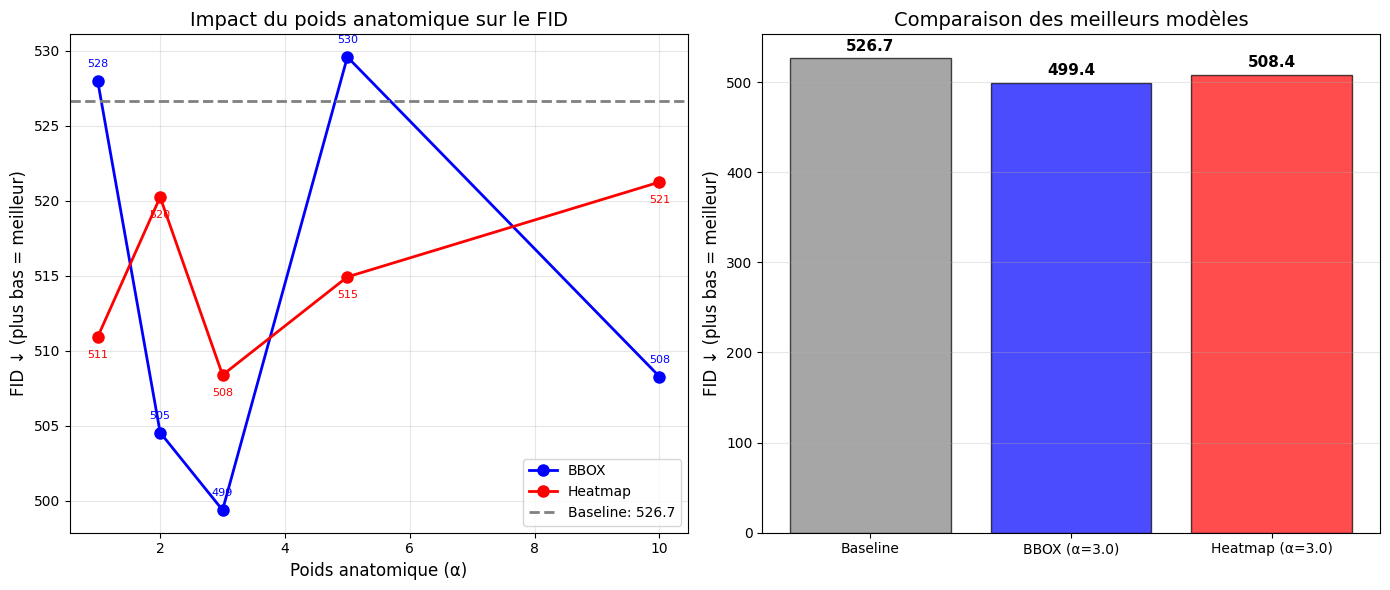

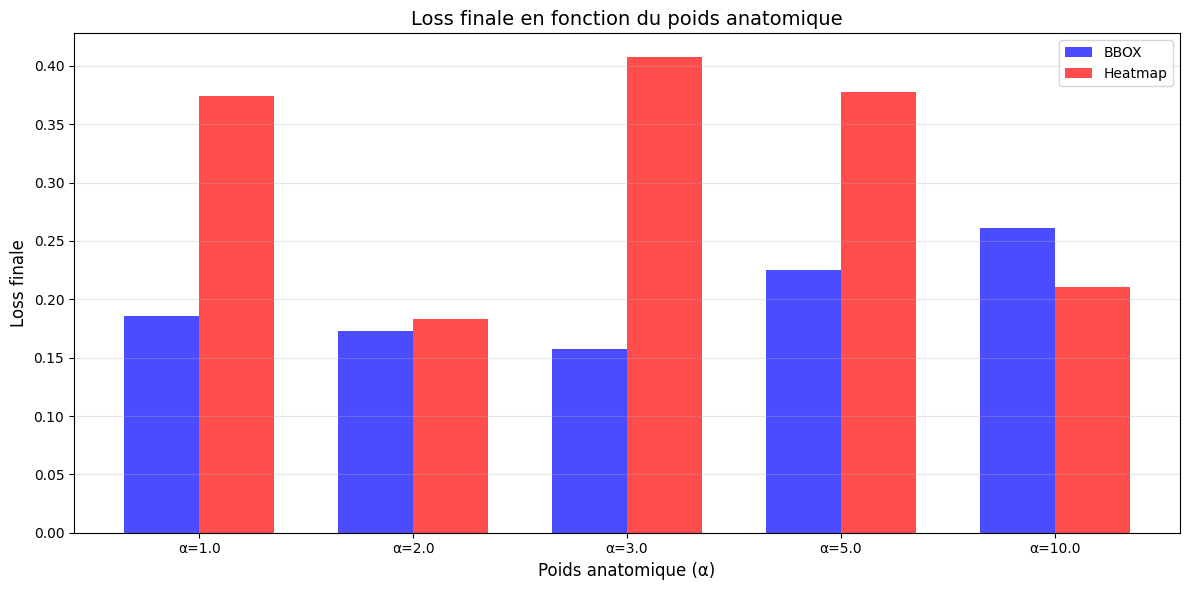


✅ Ablation study terminée !
📁 Résultats sauvegardés dans /kaggle/working/ldm_results


In [ ]:


severe_indices = [i for i, lbl in enumerate(labels) if lbl == 3]
print(f"Nombre de patches Severe réels: {len(severe_indices)}")

real_imgs = []
for idx in severe_indices[:50]:
    img = patches[idx]
    if isinstance(img, Image.Image):
        img_tensor = transforms.ToTensor()(img)
    else:
        img_tensor = img
    real_imgs.append(img_tensor)
real_imgs = torch.stack(real_imgs).to(DEVICE)
print(f"✅ {len(real_imgs)} images réelles chargées")

masks_list = []
for idx in severe_indices[:8]:
    heatmap = get_heatmap_for_patch(idx, LABELS_DIR, patch_to_image, target_size=128, sigma=15)
    if heatmap is not None:
        mask_tensor = torch.from_numpy(heatmap).float().unsqueeze(0).unsqueeze(0)
        masks_list.append(mask_tensor)

if len(masks_list) == 0:
    masks_batch = torch.ones(8, 1, 128, 128).to(DEVICE)
else:
    masks_batch = torch.cat(masks_list, dim=0).to(DEVICE)
print(f"✅ {masks_batch.shape[0]} masques préparés")

# Préparer the DataLoader for the latents (a seule fois)
latents_all, labels_all, masks_all = prepare_latent_dataset_with_masks(
    vae=vae,
    patches=patches,
    labels=labels,
    patch_to_image=patch_to_image,
    labels_dir=LABELS_DIR,
    batch_size=16
)

latent_dataset_with_masks = LatentDatasetWithMasks(latents_all, labels_all, masks_all)
latent_loader = DataLoader(latent_dataset_with_masks, batch_size=BATCH_SIZE_LDM, shuffle=True)


def train_ldm_model_with_weight(vae, latent_loader, device, model_type, weight, epochs=150):
   
    latent_unet = LatentDiffusionUNet8ch(
        in_channels=vae.latent_channels,
        out_channels=vae.latent_channels,
        num_classes=NUM_CLASSES
    ).to(device)
    
    optimizer = optim.Adam(latent_unet.parameters(), lr=LR_LDM)
    
    losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        for z, labels, masks in latent_loader:
            z = z.to(device)
            labels = labels.to(device)
            masks = masks.to(device)
            
            t = torch.randint(0, NUM_TIMESTEPS, (z.shape[0],), device=device)
            noise = torch.randn_like(z)
            z_noisy, _ = q_sample(z, t, noise)
            pred_noise = latent_unet(z_noisy, t, labels)
            
            if model_type == 'baseline':
                loss = F.mse_loss(pred_noise, noise)
            else:
                mse_per_pixel = (pred_noise - noise) ** 2
                masks_latent = F.interpolate(masks, size=z.shape[-2:], mode='nearest')
                weight_map = 1.0 + (weight - 1.0) * masks_latent
                loss = (mse_per_pixel * weight_map).mean()
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(latent_loader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 25 == 0:
            print(f"    Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    class LDMModelWrapper:
        def __init__(self, vae, unet, device, model_type):
            self.vae = vae
            self.unet = unet
            self.device = device
            self.model_type = model_type
        
        @torch.no_grad()
        def generate_with_mask(self, mask_condition, class_labels):
            batch_size = mask_condition.shape[0]
            latent_shape = (batch_size, self.vae.latent_channels, 16, 16)
            
            z = torch.randn(latent_shape, device=self.device)
            
            if mask_condition.dim() == 3:
                mask_condition = mask_condition.unsqueeze(0)
            
            for t in reversed(range(NUM_TIMESTEPS)):
                t_tensor = torch.full((batch_size,), t, device=self.device, dtype=torch.long)
                pred_noise = self.unet(z, t_tensor, class_labels)
                
                alpha_t = alphas[t]
                beta_t = betas[t]
                sqrt_recip_alpha_t = 1.0 / torch.sqrt(alpha_t)
                sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t]
                
                mean = sqrt_recip_alpha_t * (z - beta_t * pred_noise / sqrt_one_minus_alpha_cumprod_t)
                
                if t > 0:
                    z = mean + torch.sqrt(beta_t) * torch.randn_like(z)
                else:
                    z = mean
            
            return self.vae.decode(z)
    
    wrapper = LDMModelWrapper(vae, latent_unet, device, model_type)
    
    return wrapper, losses[-1]


def compute_fid_for_model(model, real_imgs, masks_batch, num_samples=50):
    """Calcule le FID pour un modèle donné"""
    model.unet.eval()
    
    all_generated = []
    
    with torch.no_grad():
        for i in range(0, num_samples, masks_batch.shape[0]):
            current_batch = min(masks_batch.shape[0], num_samples - i)
            gen = model.generate_with_mask(
                mask_condition=masks_batch[:current_batch],
                class_labels=torch.full((current_batch,), 3, device=DEVICE)
            )
            gen_01 = torch.clamp((gen + 1) / 2, 0, 1)
            all_generated.append(gen_01)
    
    all_generated = torch.cat(all_generated, dim=0)[:num_samples]
    
    fid = FrechetInceptionDistance(normalize=True).to(DEVICE)
    fid.update(real_imgs[:num_samples], real=True)
    fid.update(all_generated, real=False)
    fid_score = fid.compute().item()
    
    model.unet.train()
    return fid_score


weights_to_test = [1.0, 2.0, 3.0, 5.0, 10.0]
model_types = ['baseline', 'bbox', 'heatmap']
epochs_ablation = 150 

results = {
    'baseline': {'fids': [], 'losses': [], 'weights': [1.0]},  # baseline n'utilise pas the poids
    'bbox': {'fids': [], 'losses': [], 'weights': weights_to_test},
    'heatmap': {'fids': [], 'losses': [], 'weights': weights_to_test}
}

baseline_model, baseline_loss = train_ldm_model_with_weight(
    vae, latent_loader, DEVICE, 'baseline', weight=1.0, epochs=epochs_ablation
)
fid_baseline = compute_fid_for_model(baseline_model, real_imgs, masks_batch)
results['baseline']['fids'] = [fid_baseline]
results['baseline']['losses'] = [baseline_loss]

print("\n[2/3] Entraînement des modèles BBOX (contrainte bounding box)...")
for weight in weights_to_test:
    print(f"  Test avec α = {weight}...")
    model, loss = train_ldm_model_with_weight(
        vae, latent_loader, DEVICE, 'bbox', weight=weight, epochs=epochs_ablation
    )
    fid_score = compute_fid_for_model(model, real_imgs, masks_batch)
    results['bbox']['fids'].append(fid_score)
    results['bbox']['losses'].append(loss)
    print(f"    FID = {fid_score:.2f}, Loss = {loss:.4f}")

print("\n[3/3] Entraînement des modèles HEATMAP (contrainte anatomique)...")
for weight in weights_to_test:
    print(f"  Test avec α = {weight}...")
    model, loss = train_ldm_model_with_weight(
        vae, latent_loader, DEVICE, 'heatmap', weight=weight, epochs=epochs_ablation
    )
    fid_score = compute_fid_for_model(model, real_imgs, masks_batch)
    results['heatmap']['fids'].append(fid_score)
    results['heatmap']['losses'].append(loss)
    print(f"    FID = {fid_score:.2f}, Loss = {loss:.4f}")

# Meilleurs résultats
best_bbox_idx = np.argmin(bbox_fids)
best_heatmap_idx = np.argmin(heatmap_fids)
best_bbox_weight = weights_to_test[best_bbox_idx]
best_heatmap_weight = weights_to_test[best_heatmap_idx]



fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: FID en fonction du poids
ax1 = axes[0]
ax1.plot(weights_to_test, bbox_fids, 'o-', color='blue', linewidth=2, markersize=8, label='BBOX')
ax1.plot(weights_to_test, heatmap_fids, 'o-', color='red', linewidth=2, markersize=8, label='Heatmap')
ax1.axhline(y=baseline_fid, color='gray', linestyle='--', linewidth=2, label=f'Baseline: {baseline_fid:.1f}')

ax1.set_xlabel('Poids anatomique (α)', fontsize=12)
ax1.set_ylabel('FID ↓ (plus bas = meilleur)', fontsize=12)
ax1.set_title('Impact du poids anatomique sur le FID', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Ajouter the valeurs sur the courbes
for i, (bbox_fid, heatmap_fid) in enumerate(zip(bbox_fids, heatmap_fids)):
    ax1.annotate(f'{bbox_fid:.0f}', (weights_to_test[i], bbox_fid), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8, color='blue')
    ax1.annotate(f'{heatmap_fid:.0f}', (weights_to_test[i], heatmap_fid), 
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=8, color='red')

# Graphique 2: Comparaison of meilleurs modèles
ax2 = axes[1]
models_names = ['Baseline', f'BBOX (α={best_bbox_weight})', f'Heatmap (α={best_heatmap_weight})']
best_fids = [baseline_fid, bbox_fids[best_bbox_idx], heatmap_fids[best_heatmap_idx]]
colors = ['gray', 'blue', 'red']

bars = ax2.bar(models_names, best_fids, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('FID ↓ (plus bas = meilleur)', fontsize=12)
ax2.set_title('Comparaison des meilleurs modèles', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

for bar, fid in zip(bars, best_fids):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{fid:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_study_complete.png", dpi=150)
plt.show()

# Graphique 3: Évolution of losses
fig, ax = plt.subplots(figsize=(12, 6))

# Afficher the losses for chaque configuration
x_pos = np.arange(len(weights_to_test))
width = 0.35

ax.bar(x_pos - width/2, results['bbox']['losses'], width, label='BBOX', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, results['heatmap']['losses'], width, label='Heatmap', color='red', alpha=0.7)

ax.set_xlabel('Poids anatomique (α)', fontsize=12)
ax.set_ylabel('Loss finale', fontsize=12)
ax.set_title('Loss finale en fonction du poids anatomique', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'α={w}' for w in weights_to_test])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_losses.png", dpi=150)
plt.show()